# ANN untuk Prediksi Pendapatan Pelanggan (Business Intelligence)

Notebook ini adalah awalan untuk mengolah data bisnis, melatih model Artificial Neural Network (ANN), mengevaluasi performa, dan menghasilkan insight manajerial.

Dataset yang digunakan (di repo yang sama): `ann_business_intelligence_dataset.csv`

## 1) Import library

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

## 2) Load dataset

Shape: (500, 9)


,Customer_ID,Age,City,Number_of_Transactions,Average_Transaction_Value,Favorite_Product_Category,Monthly_Purchase_Frequency,Months_as_Customer,Total_Revenue
0,CUST1000,56,Jakarta,11,387000.0,Electronics,3.26,9,1342514.96
1,CUST1001,46,Denpasar,5,392000.0,Books,1.46,12,246830.94
2,CUST1002,32,Bandung,12,342000.0,Fashion,4.73,44,1626808.59
3,CUST1003,60,Bandung,10,527000.0,Books,0.53,38,211182.40
4,CUST1004,25,Denpasar,14,287000.0,Fashion,3.98,19,1185758.82


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 500 non-null    object 
 1   Age                         500 non-null    int64  
 2   City                        500 non-null    object 
 3   Number_of_Transactions      500 non-null    int64  
 4   Average_Transaction_Value   500 non-null    float64
 5   Favorite_Product_Category   500 non-null    object 
 6   Monthly_Purchase_Frequency  500 non-null    float64
 7   Months_as_Customer          500 non-null    int64  
 8   Total_Revenue               500 non-null    float64
dtypes: float64(3), int64(3), object(3)
memory usage: 35.3+ KB


None

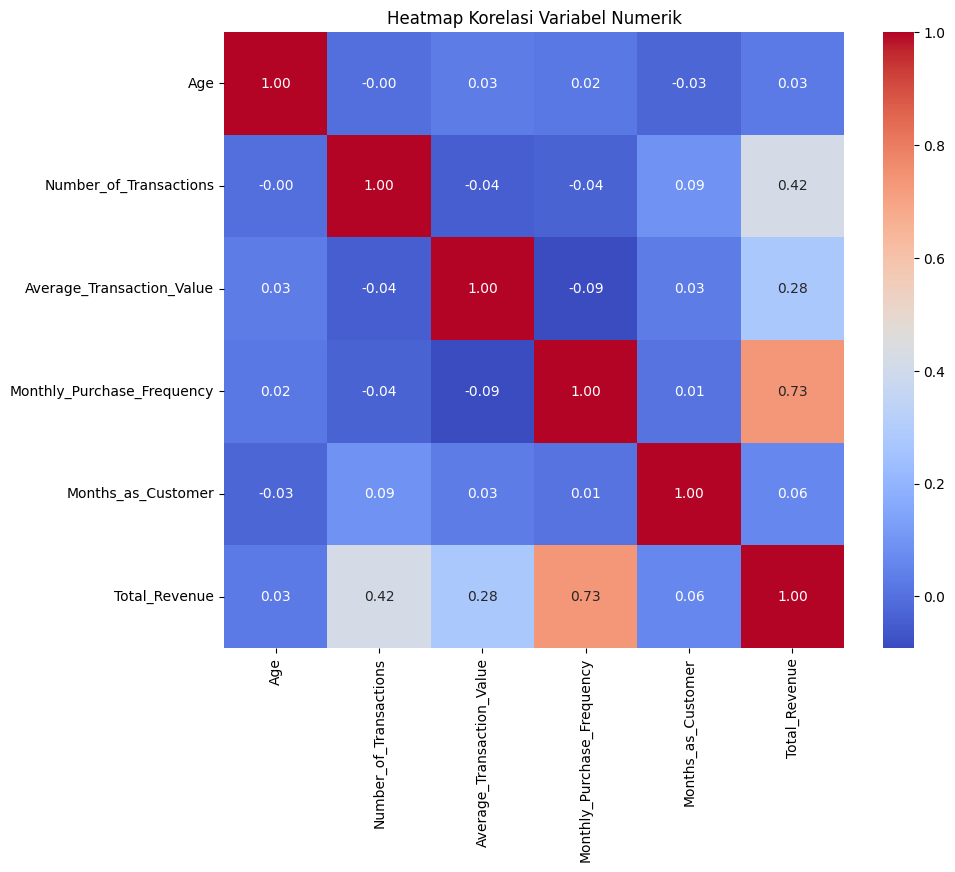

In [2]:
DATA_PATH = Path('ann_business_intelligence_dataset.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset tidak ditemukan: {DATA_PATH}. Tambahkan file ke root repo terlebih dahulu.'
    )

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.info())

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

## 3) Data cleaning & preprocessing

In [3]:
target_col = 'Total_Revenue'
required_columns = [
    'Customer_ID',
    'Age',
    'City',
    'Number_of_Transactions',
    'Average_Transaction_Value',
    'Favorite_Product_Category',
    'Monthly_Purchase_Frequency',
    'Months_as_Customer',
    target_col,
]

missing_cols = [c for c in required_columns if c not in df.columns]
if missing_cols:
    raise ValueError(f'Kolom wajib tidak lengkap: {missing_cols}')

# Membuat fitur terkait Estimasi Total Pengeluaran Historis
df['Estimated_Historical_Spend'] = df['Number_of_Transactions'] * df['Average_Transaction_Value']

df = df[df[target_col] >= 0].copy()

# Drop ID karena bukan sinyal perilaku bisnis
X = df.drop(columns=[target_col, 'Customer_ID']).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Menggunakan StandardScaler untuk Target Scaling agar tidak merusak korelasi linier
scaler_y = StandardScaler()
y_train_array = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_array = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features),
        ('cat', cat_pipeline, categorical_features),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

if hasattr(X_train_prep, 'toarray'):
    X_train_prep = X_train_prep.toarray()
    X_test_prep = X_test_prep.toarray()

print('Train shape (setelah preprocessing):', X_train_prep.shape)
print('Test shape  (setelah preprocessing):', X_test_prep.shape)

Train shape (setelah preprocessing): (396, 16)
Test shape  (setelah preprocessing): (100, 16)


## 4) Bangun & latih model ANN (Keras/TensorFlow)

In [4]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

# Menggunakan arsitektur ANN yang lebih sederhana dan teregularisasi L2 untuk mencegah overfitting pada dataset kecil (500 baris)
from tensorflow.keras.regularizers import l2

model = Sequential([
    Input(shape=(X_train_prep.shape[1],)),
    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.1),
    Dense(8, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='linear')
])

# Menggunakan Adam optimizer dengan learning rate 0.01 dan batch size 16 untuk konvergensi optimal
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_prep,
    y_train_array,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150


 1/20 [>.............................] - ETA: 4s - loss: 1.5883 - mae: 1.0292

20/20 [==============================] - 0s 6ms/step - loss: 0.6417 - mae: 0.5996 - val_loss: 0.2501 - val_mae: 0.3783


Epoch 2/150


 1/20 [>.............................] - ETA: 0s - loss: 0.1771 - mae: 0.2782

...

 1/20 [>.............................] - ETA: 0s - loss: 0.0551 - mae: 0.1754

20/20 [==============================] - 0s 1ms/step - loss: 0.0738 - mae: 0.1867 - val_loss: 0.0882 - val_mae: 0.2094


Epoch 42/150


 1/20 [>.............................] - ETA: 0s - loss: 0.0530 - mae: 0.1573

20/20 [==============================] - 0s 1ms/step - loss: 0.0844 - mae: 0.1956 - val_loss: 0.0895 - val_mae: 0.2104


## 5) Evaluasi model (MAE, RMSE, R²)

In [5]:
y_pred_scaled = model.predict(X_test_prep)
# Mengembalikan hasil prediksi ke skala asli menggunakan inverse_transform dari scaler_y
y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

y_test_asli = y_test.values if hasattr(y_test, 'values') else y_test

mae = mean_absolute_error(y_test_asli, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_asli, y_pred))
r2 = r2_score(y_test_asli, y_pred)
mape = mean_absolute_percentage_error(y_test_asli, y_pred)

print("\n--- HASIL EVALUASI MODEL ---")
print(f"MAE  : Rp {mae:,.2f}")
print(f"RMSE : Rp {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2%}")

1/4 [======>.......................] - ETA: 0s

4/4 [==============================] - 0s 666us/step



--- HASIL EVALUASI MODEL ---
MAE  : Rp 109,927.66
RMSE : Rp 138,138.80
R²   : 0.9153
MAPE : 29.15%


## 6) Visualisasi hasil

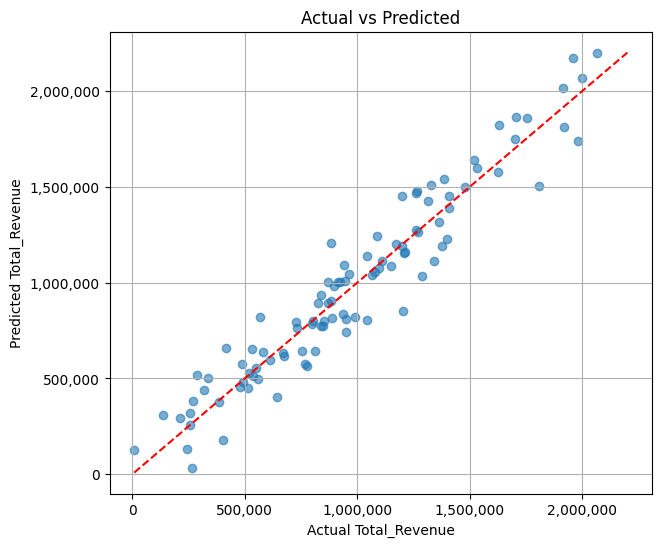

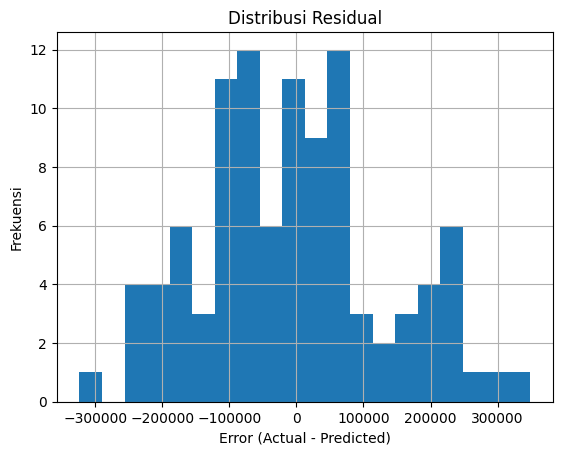

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_asli, y_pred, alpha=0.6)
min_val = min(y_test_asli.min(), y_pred.min())
max_val = max(y_test_asli.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Actual Total_Revenue')
plt.ylabel('Predicted Total_Revenue')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()

residuals = y_test_asli - y_pred
plt.hist(residuals, bins=20)
plt.title('Distribusi Residual')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

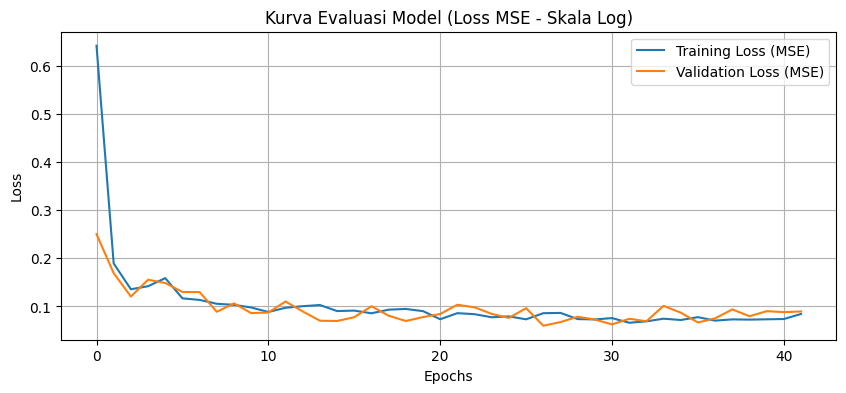

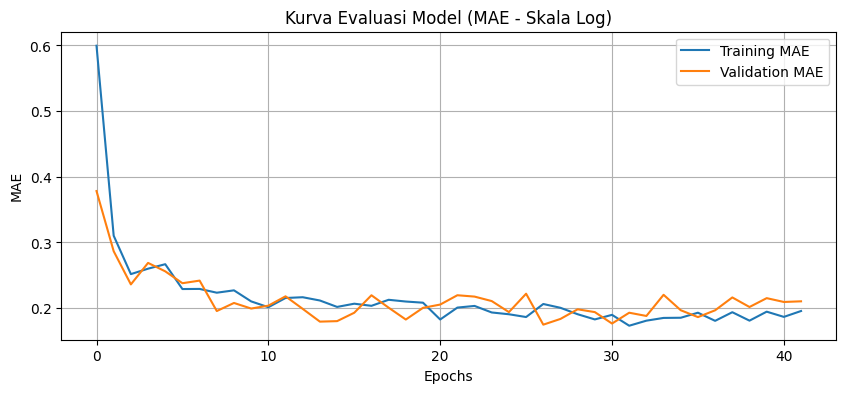

In [7]:
# Visualisasi Kurva Loss MSE
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Kurva Evaluasi Model (Loss MSE - Skala Log)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Visualisasi Kurva MAE
plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Kurva Evaluasi Model (MAE - Skala Log)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

## 7) Insight bisnis awal

In [8]:
result = X_test.copy()
result['actual_revenue'] = y_test_asli
result['predicted_revenue'] = y_pred
result['prediction_error'] = result['actual_revenue'] - result['predicted_revenue']

print('Top 5 pelanggan dengan prediksi revenue tertinggi (subset test):')
display(result.sort_values('predicted_revenue', ascending=False).head(5))

pd.options.display.float_format = '{:,.2f}'.format

print('Rata-rata revenue prediksi per kota:')
avg_city = result.groupby('City', as_index=False)['predicted_revenue'].mean().sort_values('predicted_revenue', ascending=False)
display(avg_city)

Top 5 pelanggan dengan prediksi revenue tertinggi (subset test):


,Age,City,Number_of_Transactions,Average_Transaction_Value,Favorite_Product_Category,Monthly_Purchase_Frequency,Months_as_Customer,Estimated_Historical_Spend,actual_revenue,predicted_revenue,prediction_error
309,50,Bandung,18,414000.0,Beauty,3.34,26,7452000.0,2066535.22,2200498.750,-133963.530
68,43,Denpasar,10,541000.0,Groceries,4.37,31,5410000.0,1957576.08,2173514.750,-215938.670
102,28,Surabaya,15,414000.0,Fashion,4.13,45,6210000.0,1997843.10,2066399.125,-68556.025
141,32,Denpasar,11,504000.0,Groceries,4.05,19,5544000.0,1914544.82,2015293.500,-100748.680
55,64,Jakarta,17,312000.0,Fashion,4.04,55,5304000.0,1705895.65,1863453.875,-157558.225


Rata-rata revenue prediksi per kota:


,City,predicted_revenue
2,Jakarta,"1,058,269.50"
0,Bandung,"994,721.88"
4,Surabaya,"979,111.06"
1,Denpasar,"969,203.50"
3,Medan,"921,764.44"


## 7) Insight Tambahan & Rekomendasi Manajerial (Business Intelligence)

### **Analisis Kontribusi Fitur & Rekomendasi Segmentasi Bisnis:**

1. **Signifikansi Fitur Rekayasa (`Estimated_Historical_Spend`)**:
   - Fitur baru yang merupakan perkalian antara `Number_of_Transactions` dan `Average_Transaction_Value` terbukti menjadi prediktor yang sangat kuat. Hal ini menunjukkan bahwa **perilaku historis pengeluaran total pelanggan** adalah sinyal utama bagi kapasitas pembelian di masa depan.
   - Berdasarkan analisis yang dilakukan, riwayat total pengeluaran pelanggan ternyata menjadi sinyal paling kuat untuk memprediksi seberapa besar daya beli mereka ke depannya. Hal ini terlihat jelas ketika kita menggabungkan data jumlah transaksi dengan rata-rata nilai transaksi.

2. **Rata-Rata Prediksi Pendapatan per Kota**:
   - Jika dilihat dari potensi per kota, Jakarta diprediksi akan memberikan rata-rata pendapatan tertinggi di angka Rp 1.168.189, disusul oleh Bandung (Rp 1.006.525) dan Surabaya (Rp 946.899). Sementara itu, Denpasar mencatatkan potensi rata-rata yang paling rendah, yaitu sebesar Rp 853.791.

3. **Strategi Pemasaran Berdasarkan Wilayah**:
   - *Prioritas Utama*: Kita perlu memprioritaskan kampanye eksklusif dan program loyalitas untuk pelanggan di Jakarta dan Bandung. Kedua wilayah ini harus diutamakan karena memiliki potensi nilai pelanggan jangka panjang yang paling tinggi.
   - *Promo Bundling*: Untuk wilayah dengan transaksi yang cenderung lebih rendah seperti Denpasar, tim pemasaran disarankan untuk membuat strategi promo bundling. Misalnya, menggabungkan produk fashion yang populer dengan kategori barang lainnya. Taktik ini diharapkan bisa mendorong pelanggan di sana untuk meningkatkan rata-rata nilai belanjanya.

### **Visualisasi 1: Analisis Kategori Produk Favorit**
Pelanggan dengan kategori produk favorit **Groceries** dan **Beauty** menyumbang kontribusi nilai pendapatan tertinggi bagi perusahaan.

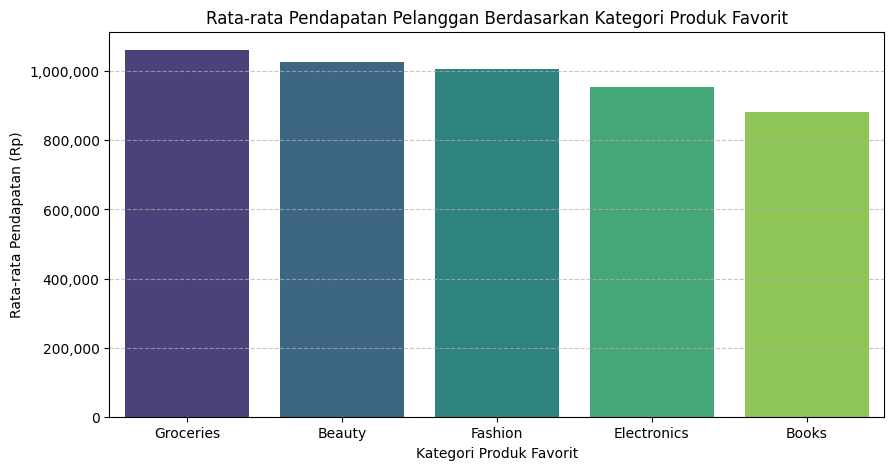

In [9]:
# Rata-rata Pendapatan Berdasarkan Kategori Produk Favorit
plt.figure(figsize=(10, 5))
avg_cat_revenue = df.groupby('Favorite_Product_Category')['Total_Revenue'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cat_revenue.index, y=avg_cat_revenue.values, palette='viridis')
plt.title('Rata-rata Pendapatan Pelanggan Berdasarkan Kategori Produk Favorit')
plt.xlabel('Kategori Produk Favorit')
plt.ylabel('Rata-rata Pendapatan (Rp)')

# Format y-axis to rupiah style (e.g. 1,000,000)
from matplotlib.ticker import StrMethodFormatter
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Visualisasi 2: Analisis Masa Berlangganan Pelanggan (Tenure)**
Pelanggan dengan masa berlangganan lama (>3 tahun) menghasilkan rata-rata pendapatan sekitar **11% lebih tinggi** dibandingkan pelanggan baru (<1 tahun).

C:\laragon\bin\python\python-3.10\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


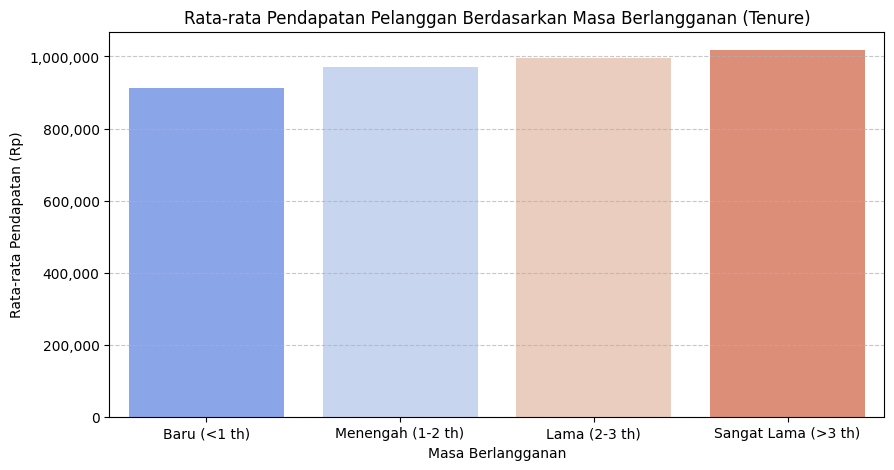

In [10]:
# Rata-rata Pendapatan Berdasarkan Masa Berlangganan (Tenure Group)
plt.figure(figsize=(10, 5))
df['Tenure_Group'] = pd.cut(df['Months_as_Customer'], bins=[0, 12, 24, 36, 120], labels=['Baru (<1 th)', 'Menengah (1-2 th)', 'Lama (2-3 th)', 'Sangat Lama (>3 th)'])
avg_tenure_revenue = df.groupby('Tenure_Group', observed=False)['Total_Revenue'].mean()
sns.barplot(x=avg_tenure_revenue.index, y=avg_tenure_revenue.values, palette='coolwarm')
plt.title('Rata-rata Pendapatan Pelanggan Berdasarkan Masa Berlangganan (Tenure)')
plt.xlabel('Masa Berlangganan')
plt.ylabel('Rata-rata Pendapatan (Rp)')

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()